# Faster version of the LoRA-N2v testing

Since calculating flux from the original stamps is time-consuming, we first compute and save the results in a CSV file. The LoRA-N2V denoising can then be performed by reading directly from the saved CSV files, avoiding repeated flux calculations.

In [1]:
import os
import pandas as pd
from pathlib import Path
import psycopg2
from astropy.io import fits
from matplotlib import pyplot as plt
from tqdm import tqdm
import copy
import torch
from photutils.aperture import aperture_photometry, CircularAperture
from photutils import CircularAnnulus, EllipticalAperture
from astropy.stats import sigma_clip
import math
from scipy.stats import norm

/tmp/ipykernel_1341/645861725.py:11: DeprecationWarning: `photutils.CircularAnnulus` is a deprecated alias for `photutils.aperture.CircularAnnulus` and will be removed in the future. Instead, please use `from photutils.aperture import CircularAnnulus` to silence this warning.
  from photutils import CircularAnnulus, EllipticalAperture
/tmp/ipykernel_1341/645861725.py:11: DeprecationWarning: `photutils.EllipticalAperture` is a deprecated alias for `photutils.aperture.EllipticalAperture` and will be removed in the future. Instead, please use `from photutils.aperture import EllipticalAperture` to silence this warning.
  from photutils import CircularAnnulus, EllipticalAperture


In [2]:
def background_annulus(data, mask, aperture_x, aperture_y, r_in=30, r_out=45):#r_in=30
    """Measure background in an annulus."""
    
    masked_data = np.ma.array(data=data, mask=mask != 0)
    masked_data = masked_data.filled(fill_value=0)

    center = (aperture_x, aperture_y)
    annulus_apertures = CircularAnnulus(center, r_in=r_in, r_out=r_out)
    masks = annulus_apertures.to_mask(method='center')

    cutout_data = masks.cutout(masked_data)

    clip_annulus_array = sigma_clip(cutout_data[cutout_data != 0], sigma=3, maxiters=2)

    S = pd.Series()
    S['annulus_mean'] = np.ma.mean(clip_annulus_array)
    S['annulus_median'] = np.ma.median(clip_annulus_array)
    S['annulus_std'] = np.ma.std(clip_annulus_array)
    S['annulus_samples'] = np.ma.count(clip_annulus_array)

    return S

def flux_elliptical(image, mask, aperture_x, aperture_y, aperture_theta, aperture_a, aperture_b):
    """Measure the flux withing an elliptical aperture."""
    
    PIXEL_SCALE = 0.263
    theta = -aperture_theta * np.pi / 180.
    a = aperture_a / PIXEL_SCALE
    b = aperture_b / PIXEL_SCALE

    center = (aperture_x, aperture_y)
    source_aperture = EllipticalAperture(center, a, b, theta)

    xmask = mask != 0
    raw_flux = aperture_photometry(image, source_aperture, mask=xmask)
   
    S = pd.Series()
    S['raw_flux'] = float(raw_flux['aperture_sum'][0])
    S['area'] = source_aperture.area
    
    return S

def cal_calerror(sig_src,sig_zp,zp,f_src):
    sig_cal = np.sqrt(sig_src**2 * sig_zp**2 + sig_src**2 * zp**2 + sig_zp**2 * f_src**2)
    return sig_cal

def cal_fcal(f_src,zp):
    f_cal = f_src * zp
    return f_cal

def creat_stamps(image, sources):
    y = math.floor(sources['aperture_x'].values[0])
    x = math.floor(sources['aperture_y'].values[0])
    #y = math.floor(sources['aperture_x'])
    #x = math.floor(sources['aperture_y'])
    x_start = max((x - cutout_size), 0)
    x_end = min((x + cutout_size), image.shape[0])
    y_start = max((y - cutout_size), 0)
    y_end = min((y + cutout_size), image.shape[1])

    stamps = image[x_start:x_end, y_start:y_end]
    return stamps

def photometry_oneimage(image, mask, aperture_x, aperture_y, aperture_theta, aperture_a, aperture_b):
    
    S1 = background_annulus(image, mask, aperture_x, aperture_y)
    S2 = flux_elliptical(image, mask, aperture_x, aperture_y, aperture_theta, aperture_a, aperture_b)

    flux_obs = S2['raw_flux'] - S2['area'] * S1['annulus_mean']
    return flux_obs

def generate_mask(size_data, image):

    num_sample = int(size_data[0] * size_data[1] * (1 - ratio))
    mask = np.ones(size_data)
    output = image

    for ich in range(size_data[2]):
        idy_msk = np.random.randint(0, size_data[0], num_sample)
        idx_msk = np.random.randint(0, size_data[1], num_sample)

        idy_neigh = np.random.randint(-size_window[0] // 2 + size_window[0] % 2, size_window[0] // 2 + size_window[0] % 2, num_sample)
        idx_neigh = np.random.randint(-size_window[1] // 2 + size_window[1] % 2, size_window[1] // 2 + size_window[1] % 2, num_sample)

        idy_msk_neigh = idy_msk + idy_neigh
        idx_msk_neigh = idx_msk + idx_neigh

        idy_msk_neigh = idy_msk_neigh + (idy_msk_neigh < 0) * size_data[0] - (idy_msk_neigh >= size_data[0]) * size_data[0]
        idx_msk_neigh = idx_msk_neigh + (idx_msk_neigh < 0) * size_data[1] - (idx_msk_neigh >= size_data[1]) * size_data[1]

        id_msk = (idy_msk, idx_msk, ich)
        id_msk_neigh = (idy_msk_neigh, idx_msk_neigh, ich)

        output[id_msk] = image[id_msk_neigh]
        mask[id_msk] = 0.0

    return output, mask

In [3]:
import os
os.chdir('../pn2v/src/pn2v')
from core import utils
from unet import UNet
device=utils.getDevice()

model = torch.load("/data/aai/scratch/jchan/denoise/PAUS/output_save/modify_pn2v/saved_models/lora_bands_median.pth", weights_only=False)

model.eval();

CUDA available? True


# We read the .csv file here 

In [4]:
combined_NB705 = pd.read_csv('/data/aai/scratch/jchan/denoise/PAUS/output_save/modify_pn2v/train_bands/faint_middle.csv')
combined_NB705 = combined_NB705.reset_index(drop=True)

In [8]:
from dask import delayed, compute
from dask.diagnostics import ProgressBar
cutout_size = 48

@delayed
def preprocess_row(index):
    path = combined_NB705['path'][index]
    row = combined_NB705.iloc[[index]]
    
    image = fits.getdata(path).copy()
    mask = fits.getdata(path.replace('.fits', '.mask.fits')).copy()
    
    stamp_image = creat_stamps(image, row).copy()
    stamp_mask = creat_stamps(mask, row).copy()
    
    if not stamp_image.dtype.isnative:
        stamp_image = stamp_image.byteswap().newbyteorder()
    
    params = {
        'mask': stamp_mask,
        'aperture_x': cutout_size + row['aperture_x'].item() - math.floor(row['aperture_x'].item()),
        'aperture_y': cutout_size + row['aperture_y'].item() - math.floor(row['aperture_y'].item()),
        'theta': row['aperture_theta'].item(),
        'a': row['aperture_a'].item(),
        'b': row['aperture_b'].item()
    }
    return stamp_image, params

num_total = len(combined_NB705)
batch_size = 128  
chunk_size = 2048 
final_flux_results = [None] * num_total

model.eval()

print(f"Action!  In total {num_total} galaxies...")

for chunk_start in range(0, num_total, chunk_size):
    chunk_end = min(chunk_start + chunk_size, num_total)
    indices = range(chunk_start, chunk_end)
    
    tasks = [preprocess_row(idx) for idx in indices]
    print(f"\n[Chunk {chunk_start}-{chunk_end}] ...")
    with ProgressBar():
        preprocessed_batch = compute(*tasks, scheduler='processes', num_workers=8)
    
    print(f"[Chunk] GPU inference (Batch Size: {batch_size})...")
    for b_start in range(0, len(preprocessed_batch), batch_size):
        b_end = min(b_start + batch_size, len(preprocessed_batch))
        mini_batch = preprocessed_batch[b_start:b_end]
        
        images_array = np.stack([item[0] for item in mini_batch])
        input_tensor = torch.from_numpy(images_array).float().unsqueeze(1).to(device)
        
        with torch.no_grad():
            denoised_tensor = model(input_tensor)
        
        denoised_numpy = denoised_tensor.squeeze(1).cpu().numpy()
        
        for i, idx_in_mini in enumerate(range(b_start, b_end)):
            stamp_denoise = denoised_numpy[i]
            p = mini_batch[i][1]
            
            res = photometry_oneimage(
                stamp_denoise, p['mask'], 
                p['aperture_x'], p['aperture_y'], 
                p['theta'], p['a'], p['b']
            )
            final_flux_results[chunk_start + b_start + i] = res

combined_NB705['flux_obs_denoised'] = final_flux_results
print("\n🎉 Finish！")

开始处理，总计 320339 条数据...

[Chunk 0-2048] 正在并行读图...
[########################################] | 100% Completed | 214.64 s
[Chunk] 正在进行 GPU 批量推理 (Batch Size: 128)...

[Chunk 2048-4096] 正在并行读图...
[########################################] | 100% Completed | 213.05 s
[Chunk] 正在进行 GPU 批量推理 (Batch Size: 128)...

[Chunk 4096-6144] 正在并行读图...
[########################################] | 100% Completed | 160.79 s
[Chunk] 正在进行 GPU 批量推理 (Batch Size: 128)...

[Chunk 6144-8192] 正在并行读图...
[########################################] | 100% Completed | 164.46 s
[Chunk] 正在进行 GPU 批量推理 (Batch Size: 128)...

[Chunk 8192-10240] 正在并行读图...
[########################################] | 100% Completed | 199.20 s
[Chunk] 正在进行 GPU 批量推理 (Batch Size: 128)...

[Chunk 10240-12288] 正在并行读图...
[########################################] | 100% Completed | 138.87 s
[Chunk] 正在进行 GPU 批量推理 (Batch Size: 128)...

[Chunk 12288-14336] 正在并行读图...
[########################################] | 100% Completed | 172.93 s
[Chunk] 正在进行 GPU 批

# $df$

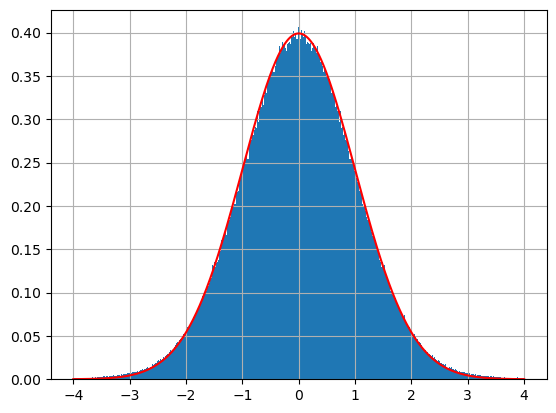

In [16]:
comb = pd.merge(combined_NB705,combined_NB705,on = ['ref_id','filter'])
comb['df'] = (comb['flux_ca_x'] - comb['flux_ca_y'])/np.sqrt(comb['flux_ca_error_x']**2 + comb['flux_ca_error_y']**2)
comb = comb[comb.image_id_x != comb.image_id_y]

comb.df.hist(bins=np.linspace(-4, 4,500), density=True)

x = np.linspace(-4, 4, 33266)
y = norm.pdf(x)
plt.plot(x, y,color='red')

In [17]:
combined_NB705['flux_ca_error'] = cal_calerror(combined_NB705['flux_error'],combined_NB705['zp_error'],combined_NB705['zp'],combined_NB705['flux_obs'])
combined_NB705['flux_ca'] = cal_fcal(combined_NB705['flux_obs'],combined_NB705['zp'])

combined_NB705['flux_ca_error_obs'] = cal_calerror(combined_NB705['flux_error'],combined_NB705['zp_error'],combined_NB705['zp'],combined_NB705['flux_obs_denoised'])
combined_NB705['flux_ca_obs'] = cal_fcal(combined_NB705['flux_obs_denoised'],combined_NB705['zp'])

combined_NB705['snr'] = combined_NB705['flux_ca_obs'] / (combined_NB705['area'] * combined_NB705['annulus_std'])

combb = pd.merge(combined_NB705,combined_NB705,on = ['ref_id','filter'])
combb['df1'] = (combb['flux_ca_x'] - combb['flux_ca_y'])/np.sqrt(combb['flux_ca_error_x']**2 + combb['flux_ca_error_y']**2)
combb['df2'] = (combb['flux_ca_obs_x'] - combb['flux_ca_obs_y'])/np.sqrt(combb['flux_ca_error_x']**2 + combb['flux_ca_error_y']**2)
combb = combb[combb.image_id_x != combb.image_id_y]

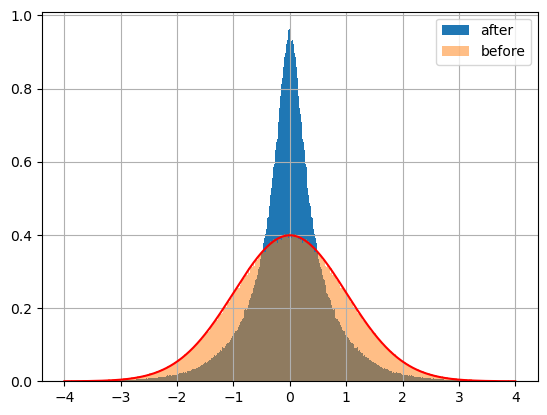

In [18]:
combb.df2.hist(bins=np.linspace(-4, 4,500), density=True,label='after')
comb.df.hist(bins=np.linspace(-4, 4,500), density=True,alpha = 0.5, label = 'before')

x = np.linspace(-4, 4, 33266)
y = norm.pdf(x)
plt.plot(x, y,color='red')
plt.legend()

# ratio

<Axes: >

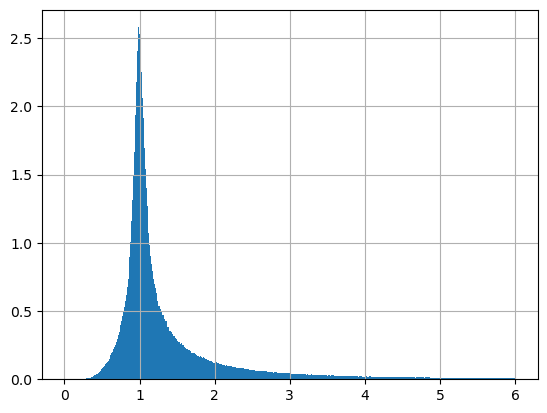

In [19]:
flux_ratio_df1 = pd.DataFrame({
    'flux_ratio': combined_NB705['flux_obs_denoised'] / combined_NB705['flux_obs']})
flux_ratio_df1.flux_ratio.hist(bins=np.linspace(-0, 6,500), density=True)